### Loading packages

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import sklearn.metrics as metrics
import scipy.cluster.hierarchy as Sciplot
import shap
import joblib
from statsmodels.stats.outliers_influence import variance_inflation_factor
from cleaning import cleaning

/bsuhome/yavarpourmohamad/miniforge3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading FPA FOD

In [2]:
nwcg = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Karen_email/NWCG_UnitIdActive_20200123.csv', sep = ',')

In [3]:
cols_FPA = ['DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'NWCG_GENERAL_CAUSE', 'Annual_etr', 'Annual_precipitation',
            'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
            'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL', 'Popo_1km', 'RPL_THEMES']

FPA_FOD = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/FPA_FOD/FPA_FOD_Plus.csv',
                      sep = ',', low_memory = False)
states = ['WA', 'OR', 'CA', 'ID', 'NV', 'MT', 'WY', 'UT', 'AZ', 'CO', 'NM']
FPA_FOD = FPA_FOD.loc[FPA_FOD['STATE'].isin(states)]
FPA_FOD = FPA_FOD.loc[FPA_FOD['LONGITUDE'] < -102.05]

FPA_FOD = pd.merge(left = FPA_FOD,
                   left_on = 'NWCG_REPORTING_UNIT_ID',
                   right = nwcg[['UnitId', 'UnitType']],
                   right_on = 'UnitId',
                   how = 'left')

FPA_FOD = FPA_FOD[(FPA_FOD['FIRE_SIZE'] >= 0.1) & (~FPA_FOD['Land_Cover'].isin([22, 23, 24])) & (~FPA_FOD['UnitType'].isin(['US County/Local']))]
FPA_FOD = FPA_FOD[cols_FPA]

In [4]:
FPA_FOD = FPA_FOD[FPA_FOD['NWCG_GENERAL_CAUSE'] == 'Natural']

In [5]:
final = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/Output/Final_0020.csv',
                    sep = ',', low_memory = False)
cols_NoF = ['DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'NWCG_GENERAL_CAUSE', 'Annual_etr', 'Annual_precipitation',
            'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
            'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL', 'Popo_1km', 'RPL_THEMES']
final = final[cols_NoF]

In [6]:
sss = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Test Dataset/Test_Dt.csv',
                  sep = ',', low_memory = False)
sss['NWCG_GENERAL_CAUSE'] = 'No_Fire'
sss = sss[cols_NoF]

In [7]:
tss4 = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Test Dataset/Test_loc_4.csv',
                  sep = ',', low_memory = False)
tss4['NWCG_GENERAL_CAUSE'] = 'No_Fire'
tss4 = tss4[cols_NoF]

In [8]:
print('FPA FOD:', FPA_FOD.shape)
print('Grid:', final.shape)
print('SSS:', sss.shape)
print('TSS-4:', tss4.shape)

FPA FOD: (231861, 29)
Grid: (36580005, 29)
SSS: (1184739, 29)
TSS-4: (526400, 29)


### Data cleaning

In [9]:
FPA_FOD, FPA_FOD_results = cleaning(df = FPA_FOD)
print(len(FPA_FOD))
FPA_FOD_results#.to_csv(path_or_buf = '/bsuhome/yavarpourmohamad/scratch/Dissertation/FPA_NAs.csv')

231183


,erc_Percentile,GHM,Popo_1km,DISCOVERY_DOY,FIRE_YEAR,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,...,Elevation_1km,Aspect_1km,Slope_1km,TPI_1km,EVC,FRG,GAP_Sts,GDP,NPL,RPL_THEMES
0,118,0,0,0,0,18,0,0,0,0,...,0,0,0,0,0,0,0,0,0,542


In [10]:
final, final_results = cleaning(df = final)
print(len(final))
final_results

36184910


,erc_Percentile,GHM,Popo_1km,DISCOVERY_DOY,FIRE_YEAR,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,...,Elevation_1km,Aspect_1km,Slope_1km,TPI_1km,EVC,FRG,GAP_Sts,GDP,NPL,RPL_THEMES
0,46533,0,0,0,0,196075,0,0,0,0,...,0,0,0,0,0,0,225,2522,0,149740


In [11]:
sss, sss_results = cleaning(df = sss)
print(len(sss))
sss_results

743949


,erc_Percentile,GHM,Popo_1km,DISCOVERY_DOY,FIRE_YEAR,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,...,Elevation_1km,Aspect_1km,Slope_1km,TPI_1km,EVC,FRG,GAP_Sts,GDP,NPL,RPL_THEMES
0,598,0,0,0,0,439547,0,0,0,0,...,0,0,0,0,0,0,16,7,0,622


In [12]:
tss4, tss4_results = cleaning(df = tss4)
print(len(tss4))
tss4_results

327543


,erc_Percentile,GHM,Popo_1km,DISCOVERY_DOY,FIRE_YEAR,FIPS_CODE,NWCG_GENERAL_CAUSE,Annual_etr,Annual_precipitation,Annual_tempreture,...,Elevation_1km,Aspect_1km,Slope_1km,TPI_1km,EVC,FRG,GAP_Sts,GDP,NPL,RPL_THEMES
0,775,0,0,0,0,195097,0,0,0,0,...,0,0,0,0,0,0,480,266,0,2239


In [13]:
mng = ['USFS', 'BLM', 'UNK', 'TRIB', 'SLB', 'SFW', 'SPR', 'SDOL', 'SDNR', 'REG', 'CITY', 'NPS', 'PVT', 'NGO',
       'FWS', 'CNTY', 'USBR', 'DOD', 'UNKL', 'RWD', 'USACE', 'OTHS', 'NRCS', 'ARS', 'DOE', 'JNT', 'OTHF', 'OTHR', 'SDC', 'BPA']

In [14]:
wus = pd.concat(objs = [FPA_FOD, final, sss, tss4])
wus.sort_values(by = ['FIRE_YEAR', 'DISCOVERY_DOY'], ascending = [True, True], inplace = True)
j = 0
labels = dict()
for i in wus['NWCG_GENERAL_CAUSE'].unique():
     if i == 'No_Fire':
          labels[i] = 0
     else:
          labels[i] = 1
     j+=1
wus['NWCG_GENERAL_CAUSE'] = wus['NWCG_GENERAL_CAUSE'].replace(to_replace = labels)

j = 0
labels = dict()
for i in mng:
    labels[i] = j
    j += 1
wus['Mang_Name'] = wus['Mang_Name'].replace(to_replace = labels)

wus = wus.astype(np.float64)
print(len(wus))

/tmp/ipykernel_20468/1806124787.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wus['NWCG_GENERAL_CAUSE'] = wus['NWCG_GENERAL_CAUSE'].replace(to_replace = labels)
/tmp/ipykernel_20468/1806124787.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wus['Mang_Name'] = wus['Mang_Name'].replace(to_replace = labels)


37487585


In [15]:
unseen = wus[wus['FIRE_YEAR'] > 2018]
wus = wus[wus['FIRE_YEAR'] < 2019]
wus = wus[wus['FIRE_YEAR'] > 1999]
# unseen.to_csv(path_or_buf = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/unseen_N_1920.csv',
#               sep = ',', index = False)

### Preparing to feed ML

In [16]:
data_X = wus.loc[:, wus.columns != 'NWCG_GENERAL_CAUSE']
data_y = wus.loc[:, wus.columns == 'NWCG_GENERAL_CAUSE']

### Train, Validation, and Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size = 0.2, random_state = 42)

y_train = pd.to_numeric(y_train['NWCG_GENERAL_CAUSE'])
y_test = pd.to_numeric(y_test['NWCG_GENERAL_CAUSE'])

print('train_X size: ', len(X_train))
print('test_X size: ', len(X_test))

train_X size:  26902026
test_X size:  6725507


### train and text distribution

[Text(0, 0, '99.55'), Text(0, 0, '0.449974')]

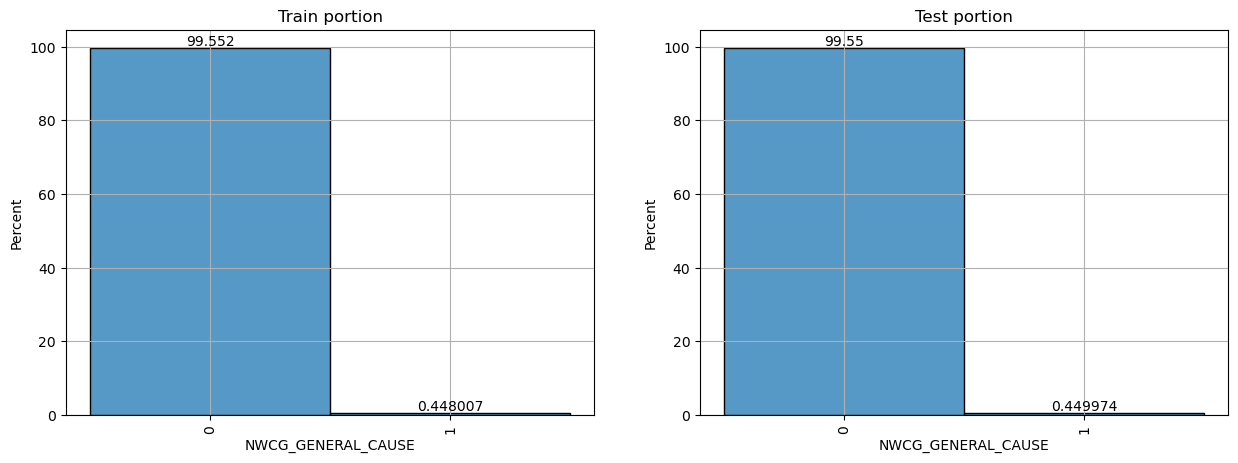

In [18]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(15, 5))

ax1 = sns.histplot(data = y_train,
                   stat = 'percent',
                   discrete = True,
                   kde = False,
                   ax = ax1)
ax1.grid()
ax1.tick_params(axis = 'x', rotation = 90)
ax1.set_xticks(ticks = np.arange(2))
ax1.set_title('Train portion')
ax1.bar_label(ax1.containers[0])

ax3 = sns.histplot(data = y_test,
                   stat = 'percent',
                   discrete = True,
                   kde = False,
                   ax = ax3)
ax3.grid()
ax3.tick_params(axis = 'x', rotation = 90)
ax3.set_xticks(ticks = np.arange(2))
ax3.set_title('Test portion')
ax3.bar_label(ax3.containers[0])

### Calculating class weights

In [19]:
cls_wght = class_weight.compute_sample_weight(class_weight = 'balanced',
                                              y = y_train)

### With Class Weight

In [20]:
# clf_XGb_ww = xgb.XGBClassifier(alpha = 1,
#                                base_score = 0.2,
#                                booster = 'gbtree',
#                                gamma = 0,
#                                learning_rate = 0.28428671223904545,
#                                max_depth =  10,
#                                min_child_weight = 1,
#                                n_estimators = 450,
#                                objective = 'binary:logistic',
#                                subsample = 1.0,
#                                tree_method = 'hist',
#                                seed = 42,
#                                )
# clf_XGb_ww.fit(X_train, y_train, sample_weight = cls_wght)

In [21]:
# joblib.dump(value = clf_XGb_ww,
#             filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_N_2000.pkl')
clf_XGb_ww = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_N_2000.pkl')

In [22]:
# joblib.dump(value = clf_XGb_ww,
#             filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_N.pkl')
# clf_XGb_ww = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_WW_N.pkl')

In [23]:
print('Precision: %.5f%%'% (metrics.precision_score(y_pred = clf_XGb_ww.predict(X_test),
                                                    y_true = y_test) * 100))
print('Recall: %.5f%%'% (metrics.recall_score(y_pred = clf_XGb_ww.predict(X_test),
                                              y_true = y_test) * 100))
print('F1 score: %.5f%%'% (metrics.f1_score(y_pred = clf_XGb_ww.predict(X_test),
                                            y_true = y_test) * 100))
print('Accuracy: %.5f%%'% (metrics.accuracy_score(y_pred = clf_XGb_ww.predict(X_test),
                                                  y_true = y_test) * 100))
print('cohen_kappa_score: %.5f%%'% (metrics.cohen_kappa_score(y1 = y_test,
                                                              y2 = clf_XGb_ww.predict(X_test)) * 100))
print('Mathew’s correlation coefficient: %.5f%%'% (metrics.matthews_corrcoef(y_true = y_test,
                                                                             y_pred = clf_XGb_ww.predict(X_test)) * 100))
print('Balanced accuracy: %.5f%%'% (metrics.balanced_accuracy_score(y_true = y_test,
                                                                    y_pred = clf_XGb_ww.predict(X_test)) * 100))

Precision: 75.09426%
Recall: 92.79648%
F1 score: 83.01212%
Accuracy: 99.82910%
cohen_kappa_score: 82.92720%
Mathew’s correlation coefficient: 83.39674%
Balanced accuracy: 96.32869%


In [24]:
unseen_2019 = unseen[unseen['FIRE_YEAR'] == 2019]
true_2019 = unseen_2019.loc[:, unseen_2019.columns == 'NWCG_GENERAL_CAUSE']
input_2019 = unseen_2019.loc[:, unseen_2019.columns != 'NWCG_GENERAL_CAUSE']
predict_2019 = clf_XGb_ww.predict(input_2019)

print('Precision for 2019: %.5f%%'% (metrics.precision_score(y_pred = predict_2019,
                                                             y_true = true_2019) * 100))
print('Recall for 2019: %.5f%%'% (metrics.recall_score(y_pred = predict_2019,
                                                       y_true = true_2019) * 100))
print('F1 score for 2019: %.5f%%'% (metrics.f1_score(y_pred = predict_2019,
                                                     y_true = true_2019) * 100))
print('Accuracy for 2019: %.5f%%'% (metrics.accuracy_score(y_pred = predict_2019,
                                                           y_true = true_2019) * 100))

Precision for 2019: 71.25633%
Recall for 2019: 87.43568%
F1 score for 2019: 78.52123%
Accuracy for 2019: 99.87435%


In [25]:
unseen_2020 = unseen[unseen['FIRE_YEAR'] == 2020]
true_2020 = unseen_2020.loc[:, unseen_2020.columns == 'NWCG_GENERAL_CAUSE']
input_2020 = unseen_2020.loc[:, unseen_2020.columns != 'NWCG_GENERAL_CAUSE']
predict_2020 = clf_XGb_ww.predict(input_2020)

print('Precision for 2020: %.5f%%'% (metrics.precision_score(y_pred = predict_2020,
                                                             y_true = true_2020) * 100))
print('Recall for 2020: %.5f%%'% (metrics.recall_score(y_pred = predict_2020,
                                                       y_true = true_2020) * 100))
print('F1 score for 2020: %.5f%%'% (metrics.f1_score(y_pred = predict_2020,
                                                     y_true = true_2020) * 100))
print('Accuracy for 2020: %.5f%%'% (metrics.accuracy_score(y_pred = predict_2020,
                                                           y_true = true_2020) * 100))

Precision for 2020: 43.39869%
Recall for 2020: 26.88985%
F1 score for 2020: 33.20553%
Accuracy for 2020: 99.77508%


Text(0, 0.5, 'True labels')

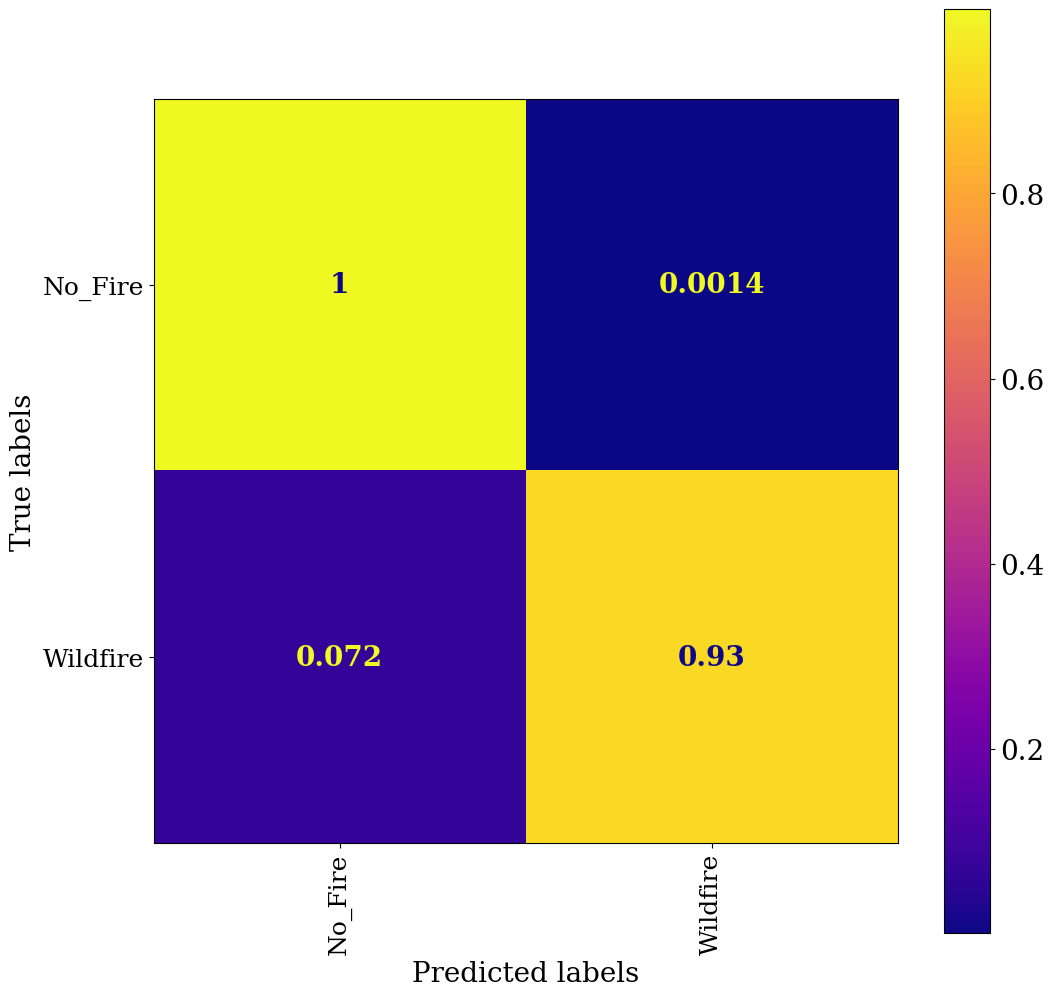

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams.update({'font.size': 20})
label_dic = {0:  'No_Fire',
             1:  'Wildfire'
             }
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12, 12))
ConfusionMatrixDisplay.from_estimator(estimator = clf_XGb_ww,
                                      X = X_test,
                                      y = y_test,
                                      display_labels = list(label_dic.values()),
                                      xticks_rotation = 'vertical',
                                      normalize = 'true',
                                      cmap = 'plasma',
                                      include_values = True,
                                      ax = ax,
                                       text_kw = {'fontsize': 20,
                                                 'fontweight': 'bold'}
                                      )
plt.tick_params(axis = 'both', labelsize = 18)
plt.xlabel(xlabel = 'Predicted labels', fontsize = 20)
plt.ylabel(ylabel = 'True labels', fontsize = 20)

In [27]:
def get_swap_dict(d):
    return {v: k for k, v in d.items()}
swap_labels = get_swap_dict(labels)

### Without Class Weight

In [28]:
# clf_XGb = xgb.XGBClassifier(alpha = 0,
#                             base_score = 0.20176222647534445,
#                             booster = 'gbtree',
#                             gamma = 0,
#                             learning_rate = 0.2738577680568722,
#                             max_depth = 10,
#                             min_child_weight = 1,
#                             n_estimators = 354,
#                             objective = 'binary:logistic',
#                             subsample = 1.0,
#                             tree_method = 'hist',
#                             seed = 42,
#                             )
# clf_XGb.fit(X_train, y_train)

In [29]:
# joblib.dump(value = clf_XGb,
#             filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_N_2000.pkl')
clf_XGb = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_N_2000.pkl')

In [30]:
# joblib.dump(value = clf_XGb,
#             filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_N.pkl')
# clf_XGb = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching roadFSless/clf_xgb_N.pkl')

In [31]:
# Calculate the precision, recall, and F1-score for each class
y_pred = clf_XGb.predict(X_test)

print('Precision: %.5f%%'% (metrics.precision_score(y_pred = y_pred,
                                                    y_true = y_test) * 100))
print('Recall: %.5f%%'% (metrics.recall_score(y_pred = y_pred,
                                              y_true = y_test) * 100))
print('F1 score: %.5f%%'% (metrics.f1_score(y_pred = y_pred,
                                            y_true = y_test) * 100))
print('Accuracy: %.5f%%'% (metrics.accuracy_score(y_pred = y_pred,
                                                  y_true = y_test) * 100))
print('cohen_kappa_score: %.5f%%'% (metrics.cohen_kappa_score(y1 = y_test,
                                                              y2 = y_pred) * 100))
print('Mathew’s correlation coefficient: %.5f%%'% (metrics.matthews_corrcoef(y_true = y_test,
                                                                             y_pred = y_pred) * 100))
print('Balanced accuracy: %.5f%%'% (metrics.balanced_accuracy_score(y_true = y_test,
                                                                    y_pred = y_pred) * 100))

Precision: 92.35420%
Recall: 82.78095%
F1 score: 87.30593%
Accuracy: 99.89168%
cohen_kappa_score: 87.25170%
Mathew’s correlation coefficient: 87.38347%
Balanced accuracy: 91.37499%


In [32]:
unseen_2019 = unseen[unseen['FIRE_YEAR'] == 2019]
true_2019 = unseen_2019.loc[:, unseen_2019.columns == 'NWCG_GENERAL_CAUSE']
input_2019 = unseen_2019.loc[:, unseen_2019.columns != 'NWCG_GENERAL_CAUSE']
predict_2019 = clf_XGb.predict(input_2019)

print('Precision for 2019: %.5f%%'% (metrics.precision_score(y_pred = predict_2019,
                                                             y_true = true_2019) * 100))
print('Recall for 2019: %.5f%%'% (metrics.recall_score(y_pred = predict_2019,
                                                       y_true = true_2019) * 100))
print('F1 score for 2019: %.5f%%'% (metrics.f1_score(y_pred = predict_2019,
                                                     y_true = true_2019) * 100))
print('Accuracy for 2019: %.5f%%'% (metrics.accuracy_score(y_pred = predict_2019,
                                                           y_true = true_2019) * 100))


Precision for 2019: 85.88533%
Recall for 2019: 79.97427%
F1 score for 2019: 82.82447%
Accuracy for 2019: 99.91288%


In [33]:
unseen_2020 = unseen[unseen['FIRE_YEAR'] == 2020]
true_2020 = unseen_2020.loc[:, unseen_2020.columns == 'NWCG_GENERAL_CAUSE']
input_2020 = unseen_2020.loc[:, unseen_2020.columns != 'NWCG_GENERAL_CAUSE']
predict_2020 = clf_XGb.predict(input_2020)

print('Precision for 2020: %.5f%%'% (metrics.precision_score(y_pred = predict_2020,
                                                             y_true = true_2020) * 100))
print('Recall for 2020: %.5f%%'% (metrics.recall_score(y_pred = predict_2020,
                                                       y_true = true_2020) * 100))
print('F1 score for 2020: %.5f%%'% (metrics.f1_score(y_pred = predict_2020,
                                                     y_true = true_2020) * 100))
print('Accuracy for 2020: %.5f%%'% (metrics.accuracy_score(y_pred = predict_2020,
                                                           y_true = true_2020) * 100))

Precision for 2020: 56.47558%
Recall for 2020: 14.36285%
F1 score for 2020: 22.90142%
Accuracy for 2020: 99.79893%


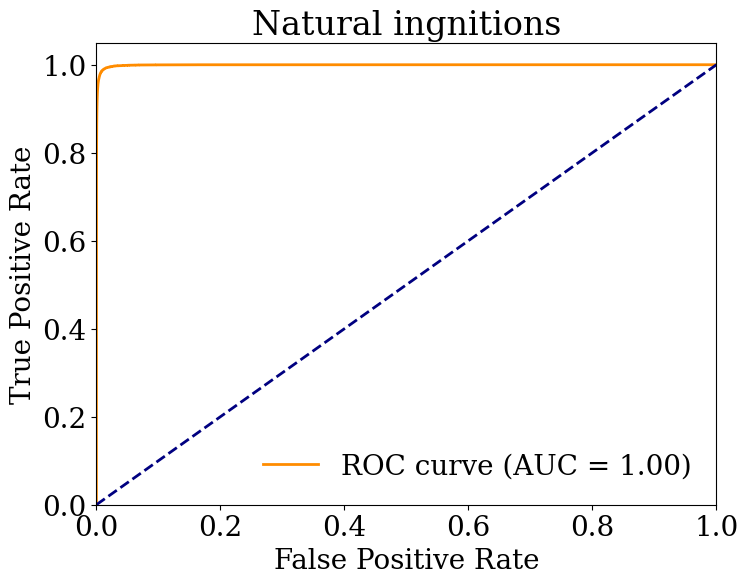

AUC: 1.00


In [34]:
from sklearn.metrics import roc_curve, auc
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams.update({'font.size': 20})
y_pred_proba = clf_XGb_ww.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Natural ingnitions')
plt.legend(loc='lower right', frameon=False)
plt.show()

print(f"AUC: {roc_auc:.2f}")

Text(0, 0.5, 'True labels')

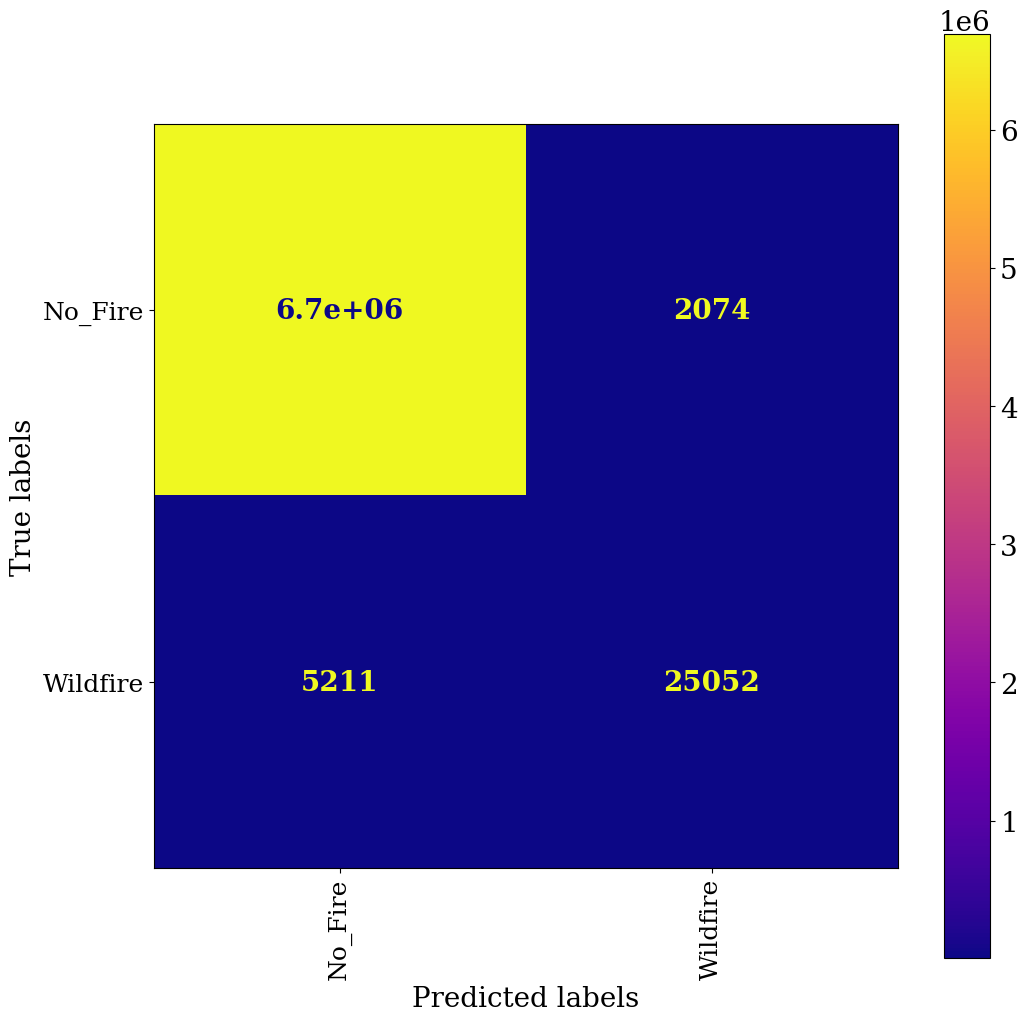

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams.update({'font.size': 20})
label_dic = {0:  'No_Fire',
             1:  'Wildfire'
             }
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12, 12))
ConfusionMatrixDisplay.from_estimator(estimator = clf_XGb,
                                      X = X_test,
                                      y = y_test,
                                      display_labels = list(label_dic.values()),
                                      xticks_rotation = 'vertical',
                                    #   normalize = 'true',
                                      cmap = 'plasma',
                                      include_values = True,
                                      ax = ax,
                                      text_kw = {'fontsize': 20,
                                                 'fontweight': 'bold'}
                                      ).confusion_matrix
plt.tick_params(axis = 'both', labelsize = 18)
plt.xlabel(xlabel = 'Predicted labels', fontsize = 20)
plt.ylabel(ylabel = 'True labels', fontsize = 20)

### Feature Importance

In [36]:
# =============================================================================
# Shapley Values for Feature Importance
# =============================================================================
shap.initjs()
explainer = shap.TreeExplainer(clf_XGb, approximate = True)
shps = X_test.sample(frac = 0.5)
shap_values = explainer.shap_values(shps)

In [ ]:
newCmapp = ['#a6cee3','#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c',
           '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928']

newCmap = LinearSegmentedColormap.from_list(name = '',
                                            colors = newCmapp,
                                            N = 2)


In [ ]:
feat_dict = {
             'Popo_1km': 'Pop_1km',
             '11': 'Open Water',
             '12': 'Snow/Ice',
             '13': 'Developed-Upland Deciduous Forest',
             '14': 'Developed-Upland Evergreen Forest',
             '15': 'Developed-Upland Mixed Forest',
             '16': 'Developed-Upland Herbaceous',
             '17': 'Developed-Upland Shrubland',
             '22': 'Developed - Low Intensity',
             '23': 'Developed - Medium Intensity',
             '24': 'Developed - High Intensity',
             '25': 'Developed-Roads',
             '31': 'Barren',
             '32': 'Quarries-Strip Mines-Gravel Pits-Well and Wind Pads',
             '61': 'NASS-Vineyard',
             '63': 'NASS-Row Crop-Close Grown Crop',
             '64': 'NASS-Row Crop',
             '65': 'NASS-Close Grown Crop',
             '68': 'NASS-Wheat',
             '69': 'NASS-Aquaculture',
             '100': 'Sparse Vegetation Canopy',
             '200': 'Shrub Cover',
             '300': 'Herb Cover',
            }
feat_name = X_train.columns.to_list()
for idx, item in enumerate(X_train.columns):
    if item in feat_dict:
        feat_name[idx] = feat_dict[item]

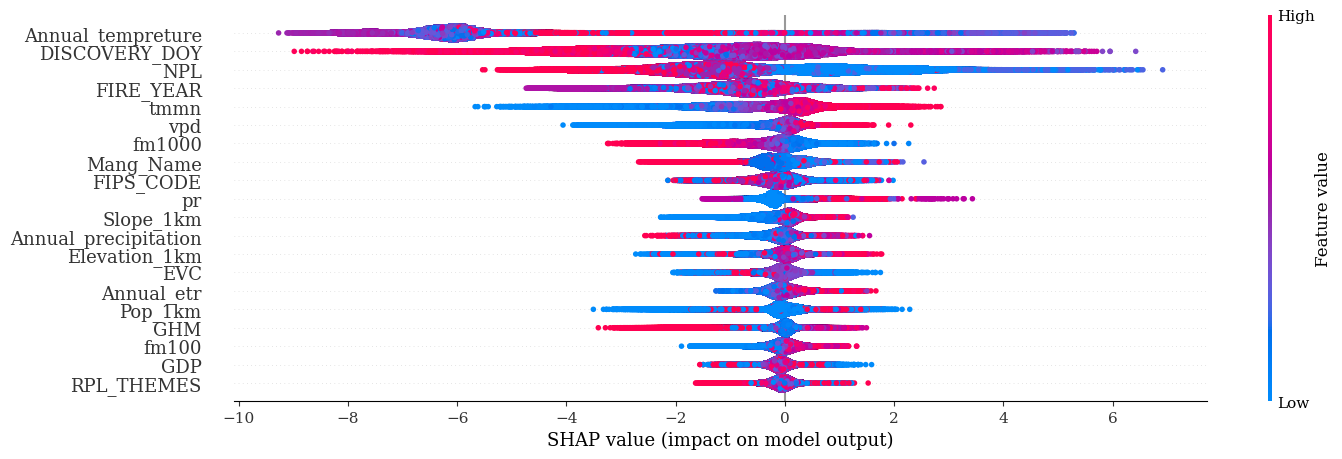

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt_shap = shap.summary_plot(shap_values,                       # Use Shap values array
                             features = shps,                # Use training set features
                             feature_names = feat_name,         # Use column names
                             show = False,                      # Set to false to output to folder
                             class_names = swap_labels,         # Converting the class from int to orginal labels [Dict class]
                             color = newCmap,                   # New set of color, it should be in 'LinearSegmentedColormap' class
                             color_bar_label = 'Feature value',
                             plot_size = (15,5),                # Change plot size
                            #  class_inds = 'original',         # It will always keep the class labels in the same order
                             )
# plt.savefig(f'/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/summary_plot_West_xgb.png')
plt.show()

In [ ]:
feature_names = X_test.columns
sh_val = np.zeros(shape = shap_values[0].shape)

for cls in range(len(shap_values)):
    sh_val = sh_val + shap_values[cls]
rf_resultX = pd.DataFrame(sh_val.reshape((1, 28)), columns = feature_names)
vals = np.abs(rf_resultX.values).mean(0)
shap_importance = pd.DataFrame(list(zip(feature_names, vals)),
                                columns = ['col_name', 'feature_importance_vals'])
shap_importance.sort_values(by = ['feature_importance_vals'],
                            ascending = False,
                            inplace = True)
shap_importance.to_csv(path_or_buf = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/feat_import_xgb_cls_N.csv',
                       sep = ',',
                       index = False)
shap_importance

,col_name,feature_importance_vals
5,Annual_tempreture,1.861701e+07
0,DISCOVERY_DOY,4.839491e+06
1,FIRE_YEAR,2.430535e+06
25,NPL,1.951194e+06
7,tmmn,1.118220e+06
12,vpd,1.077817e+06
10,fm1000,8.986025e+05
2,FIPS_CODE,4.839196e+05
4,Annual_precipitation,4.346310e+05
17,Slope_1km,4.205386e+05


# Feature importance beeswarm

In [ ]:
p

NameError: name 'p' is not defined

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

explainer = shap.Explainer(clf_XGb, X_test)
shap_values = explainer(X_test, check_additivity = False)

In [ ]:
fig, ax = plt.subplots(figsize = (15, 5))
shap.plots.bar(shap_values,
               ax = ax,
               max_display = 20,
               )

In [ ]:
shap.plots.beeswarm(shap_values,
                    max_display = 20,
                    plot_size = (15,5),
                    )